In [1]:
#other imports
import os
import numpy as np
import scipy as sp
import pickle
os.chdir('C:/Code/Github/GLM-analysis/')

In [2]:
from DataHandlerDecoding import DataHandlerDecoding as datafun
from Plotter import Plotter as plotterfun
from DecoderAnalyzer import DecoderAnalyzer as analysisdec
from AnalysisManagerEncoding import AnalysisManagerEncoding as analysisenc
from DatasetConfig import DatasetConfig

In [3]:
#initialize class
# decoded_variables= {'sound_category', 'choice', 'photostim', 'outcome','shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome'}
# decoded_variables= {'sound_category','shuffled/sound_category'}#{'choice', 'shuffled/choice'}#{'sound_category','shuffled/sound_category', 'choice', 'shuffled/choice','outcome','shuffled/outcome'}
decoded_variables=  {'outcome','shuffled/outcome'}#{'outcome','shuffled/outcome'} #{'sound_category','shuffled/sound_category'}#{'photostim','shuffled/photostim'} #{'photostim','shuffled/photostim'} #,'photostim','shuffled/photostim'}

data_handler = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed
data_handler_pass = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed

In [4]:
config = DatasetConfig()

info_dir = 'V:/Connie/results/opto_2024/context/mod'
all_datasets, mouse_dates_keys = config.load_from_info(info_dir, data_handler)
datasets, filtered_keys = config.get_datasets_with_variables(decoded_variables)
datasets, filtered_keys = config.get_specific_datasets([9,5])
# event onsets: [7,39,71,132,146]



Unique base variables: {'outcome'}
Indices to remove: {2, 7, 8, 20, 21, 22}

Filtered datasets (19):
Animal: HA11-1R, Date: 2023-05-05
Animal: HA11-1R, Date: 2023-04-13
Animal: HA2-1L, Date: 2023-05-05
Animal: HA1-00, Date: 2023-06-29
Animal: HA1-00, Date: 2023-08-28
Animal: HE4-1L1R, Date: 2023-08-21
Animal: HA10-1L, Date: 2023-04-17
Animal: HA10-1L, Date: 2023-04-12
Animal: HA11-1R, Date: 2023-04-07
Animal: HA11-1R, Date: 2023-05-01
Animal: HA11-1R, Date: 2023-05-02
Animal: HA2-1L, Date: 2023-04-28
Animal: HA2-1L, Date: 2023-05-01
Animal: HA1-00, Date: 2023-06-27
Animal: HA1-00, Date: 2023-07-07
Animal: HA1-00, Date: 2023-08-25
Animal: HE4-1L1R, Date: 2023-08-14
Animal: HA10-1L, Date: 2023-03-31
Animal: HE1-00, Date: 2023-05-30

Loading specific datasets:
Animal: HA10-1L, Date: 2023-04-17
Animal: HA1-00, Date: 2023-08-28


In [5]:
#LOAD ACTUAL DATASETS 
save_results = os.path.join(f'V:/Connie/results/glm_decoding/prelim')
os.makedirs(save_results, exist_ok=True)
cat_results = []
cat_results_pass = []

model_type = 'GLM_3nmf_pre'
results_pre,results_pre_all_sb, cat_results, celltype_info = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives means across sc or pop
if 'photostim' in decoded_variables or 'sound_category' in decoded_variables:
    model_type = 'GLM_3nmf_passive'
    results_pass,results_pass_all_sb, cat_results_pass, celltype_info = data_handler_pass.process_multiple_datasets(datasets, model_type,single_balanced=True) 

Processing dataset: HA10-1L_2023-04-17
V:/Connie/ProcessedData/HA10-1L/2023-04-17/GLM_3nmf_pre/decoding/1_1/
decoder_results_regular_outcome.mat
decoder_results_shuffled_outcome.mat
V:/Connie/ProcessedData/HA10-1L/2023-04-17/GLM_3nmf_pre/decoding/2_1/
decoder_results_regular_outcome.mat
decoder_results_shuffled_outcome.mat
V:/Connie/ProcessedData/HA10-1L/2023-04-17/GLM_3nmf_pre/decoding/3_1/
decoder_results_regular_outcome.mat
decoder_results_shuffled_outcome.mat
V:/Connie/ProcessedData/HA10-1L/2023-04-17/GLM_3nmf_pre/decoding/4_1/
decoder_results_regular_outcome.mat
decoder_results_shuffled_outcome.mat
V:/Connie/ProcessedData/HA10-1L/2023-04-17/GLM_3nmf_pre/decoding/5_1/
decoder_results_regular_outcome.mat
decoder_results_shuffled_outcome.mat
V:/Connie/ProcessedData/HA10-1L/2023-04-17/GLM_3nmf_pre/decoding/6_1/
decoder_results_regular_outcome.mat
decoder_results_shuffled_outcome.mat
V:/Connie/ProcessedData/HA10-1L/2023-04-17/GLM_3nmf_pre/decoding/7_1/
decoder_results_regular_outcome.m

In [6]:
def save_process_multiple_datasets_output(output, filename):
    """
    Save the output of process_multiple_datasets to a file using pickle.
    
    Parameters:
    - output: The output of process_multiple_datasets
    - filename: str, the filename to save the output
    """
    with open(filename, 'wb') as file:
        pickle.dump(output, file)
    print(f"Output saved to {filename}")


def load_all_pickles_from_directory(directory):
    """
    Load all pickled files from a given directory.
    
    Parameters:
    - directory: str, the directory to search for pickled files
    
    Returns:
    - dict: A dictionary where keys are filenames (without .pkl extension) and values are the loaded data
    """
    data_dict = {}
    
    # Iterate over all files in the directory
    for filename in os.listdir(directory):
        if filename.endswith('.pkl'):
            filepath = os.path.join(directory, filename)
            with open(filepath, 'rb') as file:
                data = pickle.load(file)
                # Use the filename without the .pkl extension as the key
                key = os.path.splitext(filename)[0]
                data_dict[key] = data
                print(f"Data loaded from {filename}")
    
    return data_dict

In [7]:
# import pickle
# #save as pickled files so we can load them faster?
# save_process_multiple_datasets_output(results_pre, os.path.join(save_results,'choice,' 'results_pre.pkl'))
# save_process_multiple_datasets_output(results_pre, os.path.join(save_results,'choice,' 'results_pre_all_sb.pkl'))
# save_process_multiple_datasets_output(results_pass, os.path.join(save_results, 'results_pass.pkl'))
# save_process_multiple_datasets_output(results_pass, os.path.join(save_results, 'results_pass_all_sb.pkl'))
#save_process_multiple_datasets_output(cat_results, os.path.join(save_results,'choice,' 'cat_results.pkl'))
# save_process_multiple_datasets_output(cat_results_pass, os.path.join(save_results,'choice,' 'cat_results_pass.pkl'))
# save_process_multiple_datasets_output(celltype_info, os.path.join(save_results,'choice,' 'celltype_info.pkl'))


In [8]:
#Initialize plotting class

plotter = plotterfun(data = None, save_results= save_results)
#initialize analysis class from encoding bc we are using the same functions
analysisenc = analysisenc(data = None, plotter = plotter)

In [9]:
# Get shuffled data into frames x neurons x total shuffles across splits (50 * 10 = 500)
print(list(decoded_variables)[1])
shuffled_structure = data_handler.create_shuffled_distribution_structure(decoder_type = list(decoded_variables)[0], metric = 'sc_instantaneous_information')
if 'photostim' in decoded_variables or 'sound_category' in decoded_variables:
    shuffled_structure_pass = data_handler_pass.create_shuffled_distribution_structure(decoder_type = list(decoded_variables)[0], metric = 'sc_instantaneous_information')
  

shuffled/outcome
HA10-1L_2023-04-17
HA1-00_2023-08-28


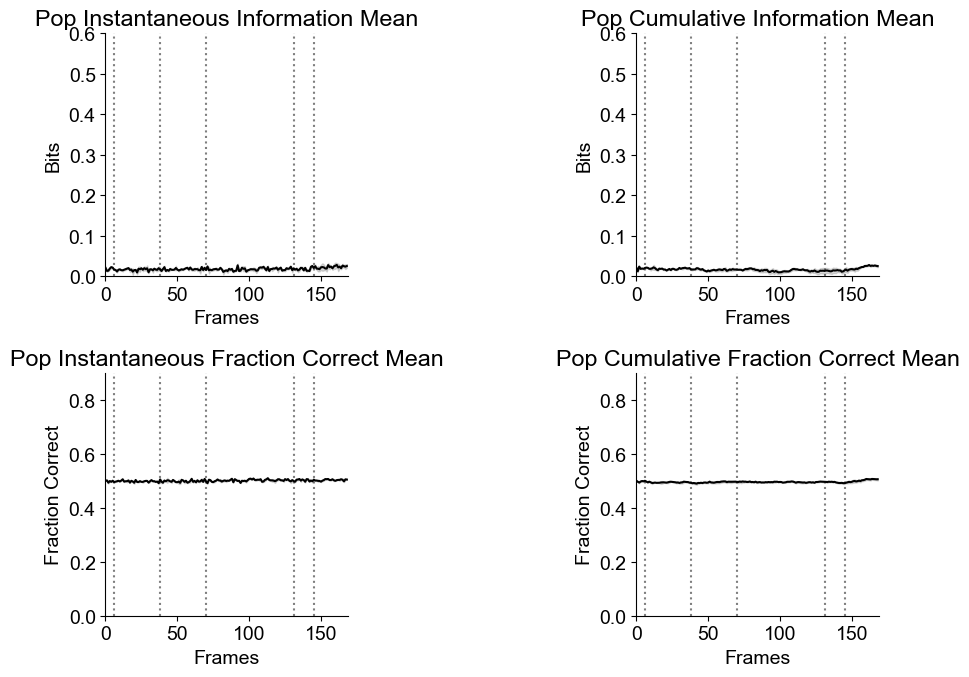

In [10]:
# Plot population decoders across datasets
current_model_type = 'pre'
results_pre_all = results_pre_all_sb
current_decoder_type = list(decoded_variables)[1] #'choice'   
os.makedirs(f'{plotter.save_results}/{current_model_type}/', exist_ok=True)

# Usage example:
plotter.plot_decoding_results(results_pre_all, 
                     decoder_type= current_decoder_type,
                     plot_type='pop', # or sc
                     save_dir= None, #f'{plotter.save_results}/{current_model_type}', #,save_dir = f'{save_results}/{current_decoder_type}_{current_model_type}_pop'
                     xlim = (0,169),
                     ylim = [0.6, 0.6, .9, .9]) #define y limits for each subplot

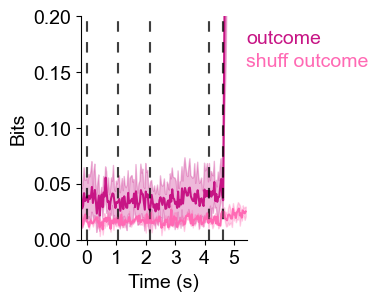

 (array([0.03881875, 0.03378318, 0.0395652 , 0.03656106, 0.03892203,
       0.04731306, 0.03290528, 0.0383291 , 0.04459983, 0.03491703,
       0.02344801, 0.03107206, 0.03951223, 0.02163595, 0.03703868,
       0.04044215, 0.02908663, 0.04230711, 0.03872787, 0.05558773,
       0.0423046 , 0.0340125 , 0.03438283, 0.02705519, 0.03427917,
       0.03851695, 0.04148228, 0.04094807, 0.03405434]), array([0.01609277, 0.01568374, 0.01156696, 0.0160638 , 0.01698209,
       0.01489704, 0.01469951, 0.01609734, 0.01776407, 0.01896672,
       0.02012461, 0.01543265, 0.01647318, 0.01125152, 0.01502079,
       0.01559576, 0.00925074, 0.01850662, 0.01716434, 0.01963476,
       0.01595506, 0.01989203, 0.01756327, 0.01957282, 0.0098332 ,
       0.01710154, 0.01703945, 0.01447553, 0.01864579])) 
Bonferroni corrected alpha threshold: 0.05000


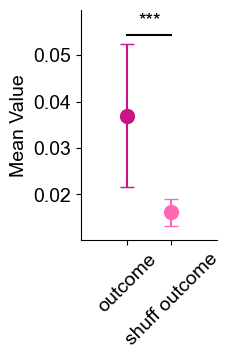

([3.725290298461914e-09], [3.725290298461914e-09])

In [11]:
# List of mean_results and corresponding decoder types
mean_results_list = [results_pre_all_sb, results_pre_all_sb]# [results_pre_all_sb, results_pre_all_sb]#[results_pre_all_sb, results_pre_all_sb]#[results_pre_all_sb, results_pass_all_sb]
current_decoded_variable = 'outcome'
decoder_types = [current_decoded_variable,f'shuffled/{current_decoded_variable}'] #['sound_category','sound_category'] #['sound_category','sound_category'] #['choice','shuffled/choice'] ##['sound_category','sound_category'] #['photostim','photostim'] #['outcome', 'shuffled/outcome']

# Plot population decoders across datasets
current_model_type = 'bothshuffled'#'pre' or passive
data_type = 'information'

if data_type == 'information':
    ylabel = 'Bits'
    ylimss = (0.0,.2)
else:
    ylabel = '% Accuracy'
    ylimss = (0.45,.8)
current_decoder_type = decoder_types[0]
save_dir_contexts = f'{plotter.save_results}/{current_model_type}_instantaneous_{data_type}_{current_decoder_type}' 

# Determine labels based on mean_results_list
try:
    # First check if results_pass_all_sb exists and is part of mean_results_list
    if 'results_pass_all_sb' in locals() and mean_results_list == [results_pre_all_sb, results_pass_all_sb]:
        labels = ['Active', 'Passive']
    else:
        labels = [current_decoded_variable, f'shuff {current_decoded_variable}']
except NameError:
    # If results_pass_all_sb doesn't exist, use decoded variable labels
    labels = [current_decoded_variable, f'shuff {current_decoded_variable}']


colors_used = plotter.default_variable_colors[current_decoded_variable]#['mediumvioletred','hotpink']#['saddlebrown','darkorange'] #['steelblue','lightskyblue'] #colors for the bar plot     
frames_used = np.arange(6,35) #frames to plot in the bar/scatter plot (7,22)
os.makedirs(save_dir_contexts , exist_ok=True)


# Plot the selected metric and get concatenated means and SEMs
concatenated_means, concatenated_sems = plotter.plot_selected_metric_with_sem(mean_results_list, decoder_types, 
                                                                      metric=f'pop_instantaneous_{data_type}_mean', 
                                                                      title= None, 
                                                                      xlabel='Seconds', 
                                                                      ylabel= ylabel, #'SC Metric 1 Value',
                                                                      ylim = ylimss, #(0.01,.03)
                                                                      xlim = (0,169), #in terms of frames (30 frames = 1 second)
                                                                    save_dir=None,#save_dir_contexts,
                                                                    labels = labels,
                                                                    colors = colors_used)


# create bar or scatter plot of mean values at specific range of values
plotter.simple_plot_wrapper(labels, concatenated_means, concatenated_sems,plot_type = 'scatter', colors= colors_used, frames = frames_used, ylabel = 'Mean Value', save_dir = None)


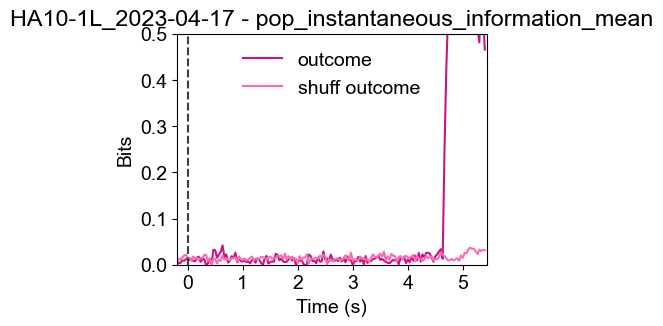

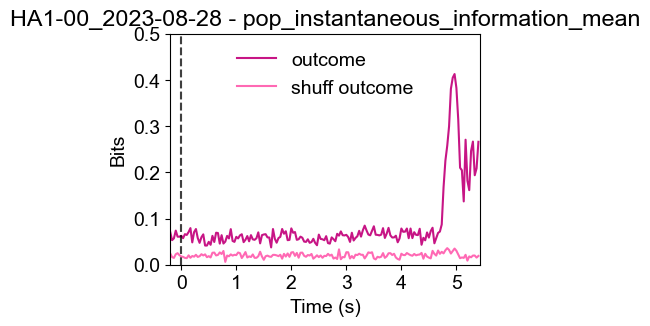

In [12]:
# Plot individual datasets the selected metric and get concatenated means and SEMs

os.makedirs(f'V:/Connie/results/glm_decoding/{current_decoded_variable}_decoding', exist_ok=True)
for dataset_key in results_pre_all_sb:
  # dataset_key = list(results_pre_all_sb.keys())[0]
  plotter.plot_dataset_metric_with_sem(mean_results_list,dataset_key, decoder_types,  
                            title= None, 
                            metric = f'pop_instantaneous_information_mean',
                            start_frame=0,
                            xlabel='Seconds', 
                            ylabel= ylabel, #'SC Metric 1 Value',
                            ylim = (0.0,.5), #ylimss, #(0.01,.03)
                            xlim = (0,169), #in terms of frames (30 frames = 1 second)
                          save_dir='V:\Connie/results\glm_decoding\sound_decoding', #,#save_dir_contexts,
                          labels = labels,
                          colors = colors_used)       

In [13]:
# Create an instance of AnalysisManager, passing in the plotter module
analysis_dec = analysisdec(celltype_info)

In [14]:
# #when testing specific datasets
# dataset_to_test = ('HE1-00_2023-05-30','HA1-00_2023-08-28') #('HA1-00_2023-08-28', 'HA1-00_2023-08-25','HA10-1L_2023-04-17') #('HA10-1L_2023-03-31') #
# results_to_test = {dataset: results_pre_all_sb[dataset] for dataset in dataset_to_test}

In [15]:
results_pre_all_sb['HA10-1L_2023-04-17']['shuffled/outcome'].keys()

dict_keys(['pop_instantaneous_information_mean', 'pop_instantaneous_information_std', 'pop_cumulative_information_mean', 'pop_cumulative_information_std', 'pop_instantaneous_fraction_correct_mean', 'pop_instantaneous_fraction_correct_std', 'pop_cumulative_fraction_correct_mean', 'pop_cumulative_fraction_correct_std', 'sc_instantaneous_information_mean', 'sc_instantaneous_information_std', 'sc_cumulative_information_mean', 'sc_cumulative_information_std', 'sc_instantaneous_fraction_correct_mean', 'sc_instantaneous_fraction_correct_std', 'sc_cumulative_fraction_correct_mean', 'sc_cumulative_fraction_correct_std', 'event_frame_mean', 'event_frame_std'])

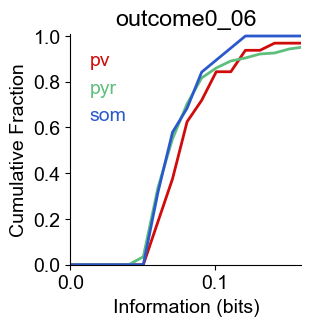

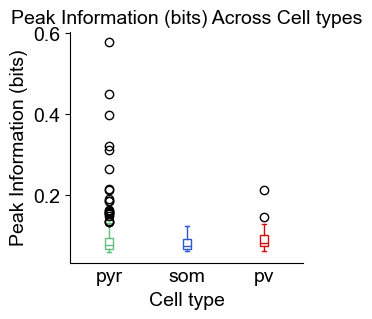

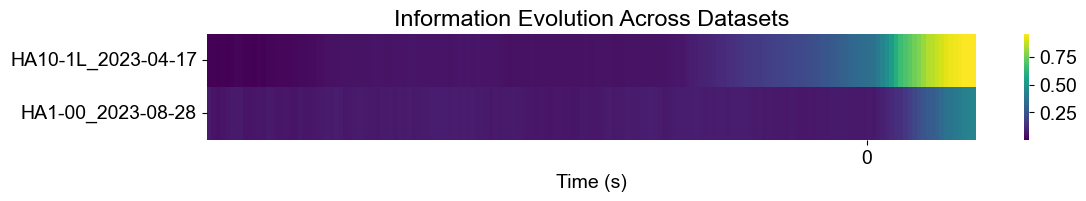

Cell type: pyr, Number of significant neurons: 229
Cell type: som, Number of significant neurons: 19
Cell type: pv, Number of significant neurons: 32
Cell type: all, Number of significant neurons: 280


In [ ]:
#DECIDE WHETHER OR NOT TO USE END FRAME
current_model_type = 'both' #'pre' or passive
results_pre_all = results_pre_all_sb #results_to_test #results_pre_all_sb
start_frame = 14 #14 before this there is artifact
end_frame = 169 #100 for sound/photostim
threshold =  0.06 #use threshold OR percentile to decide signficant neurons
method = 'range_threshold'# 'shuffled_peak', 'threshold_peak', 'range_threshold', 'combined'
metric_to_plot = 'sc_instantaneous_information_mean'
current_decoder_type = 'outcome'

# Replace dot with underscore in threshold for directory name
threshold_str = str(threshold).replace('.', '_')
save_path = f'{plotter.save_results}/{current_model_type}{start_frame}{current_decoder_type}/'
os.makedirs(save_path , exist_ok=True)

# Analyze peaks by cell type
peaks_by_celltype = []
peaks_by_celltype = analysis_dec.analyze_peaks_by_celltype( results_pre_all,shuffled_structure, method = method,
                                                            decoder_type=current_decoder_type, start_frame=start_frame , end_frame = end_frame,
                                                            significance_percentile = 5, threshold = threshold) #, end_frame = 100

#PLOT DISTRIBUTIONS OF SIGINIFICANT NEURONS!

cdf_data, cell_labels = analysis_dec.format_peaks_for_cdf(peaks_by_celltype,metric = metric_to_plot, significant_only=True)
all_peaks, neuron_groups = analysis_dec.format_peaks_for_boxplot(peaks_by_celltype, metric = metric_to_plot, significant_only=True)

#cdf
if "shuffled" in current_decoder_type:
    current_decoder_type = current_decoder_type.replace('/', '_') #replace / with _
plotter.plot_cdf_coupling_index(np.array(cdf_data['all']['peaks']),
                                cell_labels,
                                colors = plotter.celltypecolors,
                                title=f'{current_decoder_type}{threshold_str}',
                                xlabel = 'Information (bits)',
                                xval=.15,
                                xint=0.1,
                                save_path=f'{save_path}{current_decoder_type}_cdf_thr{threshold_str}.pdf',
                                perform_stats=True)

#make boxplot!
plotter.box_plot(
    data=all_peaks,
    neuron_groups=neuron_groups,
    colors=plotter.celltypecolors,
    measure_string='Peak Information (bits)',
    save_path=f'{save_path}{current_decoder_type}_box_plot_thr{threshold_str}.pdf'
)

#heatmap across datasets
plotter.plot_decoding_heatmap_datasets(results_pre_all, decoder_type= current_decoder_type, metric = 'pop_cumulative_information_mean')

# PRINT OUT # OF SIGNIFICANT NEURONS PER CELL TYPE
# Assuming cdf_data is a dictionary with cell types as keys and peaks as values
for cell_type, data in cdf_data.items():
    if 'peaks' in data:
        num_significant_neurons = len(np.array(data['peaks']))
        print(f'Cell type: {cell_type}, Number of significant neurons: {num_significant_neurons}')


In [17]:
def visualize_single_neuron_analysis(results_dict,shuffled_structure , plotter, analyzer, decoder_type='sound_category', start_frame=14, end_frame=None, metric = 'sc_instantaneous_information_mean', significance_percentile = 95, threshold = None,method = 'shuffled_peaks', save_path=None):
    """Orchestrate single neuron analysis and visualization."""

    significant_neurons_data, significance_struc, significant_neurons = analyzer.analyze_significant_neurons(results_dict,shuffled_structure,method, decoder_type, start_frame, end_frame,metric ,significance_percentile, threshold = threshold)
    
    # Plot the heatmap, only using significant neurons if they exist
    #plotter.plot_neuron_performance_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons) #separated by datasets

    plotter.plot_significant_neurons_distribution(significance_struc,save_path=f'{save_path}_hist.svg') 

    plotter.plot_time_course_by_cell_type(results_dict, decoder_type, start_frame = start_frame, end_frame = end_frame, metric = metric, significance_struc = significance_struc)

    plotter.plot_summary_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significance_struc,save_path=f'{save_path}_heatmap.svg') #combined across datasets

    plotter.plot_significant_neuron_percentages_by_celltype(significance_struc, celltype_info,  save_path=f'{save_path}.png')

    # Add these debug prints after analyze_significant_neurons:
    print("Structure of significance_struc:")
    for dataset in significance_struc:
        for celltype in significance_struc[dataset]:
            if celltype != 'sig_neurons_all':
                print(f"Dataset: {dataset}, Celltype: {celltype}, Neurons: {len(significance_struc[dataset][celltype]['neuron_indices'])}")
        print(f"Dataset: {dataset}, All sig neurons: {len(significance_struc[dataset]['sig_neurons_all'])}")

    print("\nStructure of significant_neurons:")
    if isinstance(significant_neurons, np.ndarray):
        print(f"Total significant neurons: {len(significant_neurons)}")
    else:
        print(f"Type of significant_neurons: {type(significant_neurons)}")


    return significant_neurons_data, significance_struc, significant_neurons

In [18]:
# significant_neurons_data, significance_struc = analysis_dec.analyze_significant_neurons(results_pre_all_sb,shuffled_structure,method, current_decoder_type, 14, 169,'sc_instantaneous_information_mean' ,95, threshold = threshold)
# sig_neurons['HA10-1L_2023-04-17'].shape

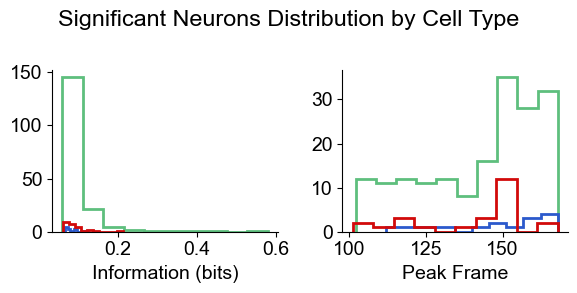

<Figure size 640x480 with 0 Axes>

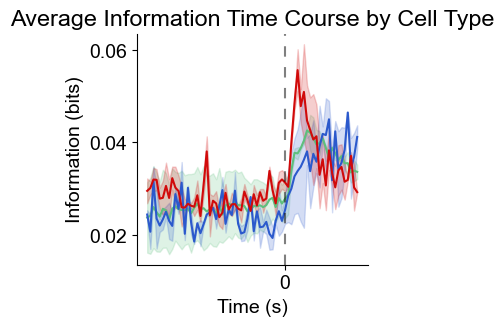

Sig neurons total 217


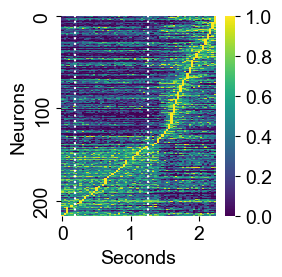

Total significant neurons across all datasets: 217
Total neurons across all datasets: 628


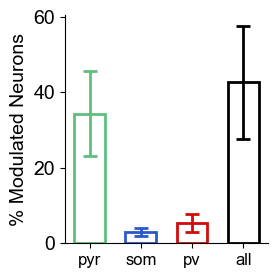

Significantly Modulated Neurons (% ± SEM):
pyr: 34.32 ± 11.27%
som: 3.02 ± 1.16%
pv: 5.32 ± 2.46%
all: 42.67 ± 14.89%
Structure of significance_struc:
Dataset: HA10-1L_2023-04-17, Celltype: pyr, Neurons: 80
Dataset: HA10-1L_2023-04-17, Celltype: som, Neurons: 6
Dataset: HA10-1L_2023-04-17, Celltype: pv, Neurons: 8
Dataset: HA10-1L_2023-04-17, All sig neurons: 94
Dataset: HA1-00_2023-08-28, Celltype: pyr, Neurons: 97
Dataset: HA1-00_2023-08-28, Celltype: som, Neurons: 9
Dataset: HA1-00_2023-08-28, Celltype: pv, Neurons: 17
Dataset: HA1-00_2023-08-28, All sig neurons: 123

Structure of significant_neurons:
Type of significant_neurons: <class 'dict'>


In [24]:
# Call the visualization function
threshold = 0.06
significant_neurons_data, sig_struct, sig_neurons = visualize_single_neuron_analysis(
    results_dict=results_pre_all_sb,
    shuffled_structure = shuffled_structure,
    method = 'range_threshold', #threshold_peak', 'range_threshold'
    plotter=plotter,
    analyzer =analysis_dec,
    decoder_type = current_decoder_type,  # Or your preferred decoder type
    start_frame = 101,#14                 # Specify start frame
    end_frame = 169,  #100                  # Specify end frame if needed, else None
    metric = 'sc_instantaneous_information_mean', #choose sc metric to look at
    significance_percentile = 95,         #used to determine significant cells
    threshold = threshold ,                   #None or 0.06 (from Runyan 2017)
    save_path= None #f'{save_path}{current_decoder_type}_sig_cel_thr{str(threshold)}'
)

# # Save significant neurons data to a .mat file
# mat_file_path = os.path.join(save_path, f'significant_neurons_data_none.mat')
# sp.io.savemat(mat_file_path, significant_neurons_data)


In [20]:
# Function to sanitize field names for MATLAB
def sanitize_field_name(name):
    return ''.join(['_' if not c.isalnum() and c != '_' else c for c in name])

# Prepare data for saving
matlab_data = {}
for dataset, celltypes in significant_neurons_data.items():
    print(dataset)
    sanitized_dataset = sanitize_field_name(dataset)
    matlab_data[sanitized_dataset] = {}
    for celltype, indices in celltypes.items():
        sanitized_celltype = sanitize_field_name(celltype)
        
        if indices is None:
            peaks = [peaks_by_celltype[dataset][celltype]['sc']['sc_instantaneous_information_mean']['peak_values'][index] for index in indices]
            # Add one to each index for MATLAB indexing
            indices = [index + 1 for index in indices]
            matlab_data[sanitized_dataset][sanitized_celltype] = {
                'indices': indices,
                'peaks': peaks
            }
# # Prepare data for saving
# matlab_data = {}
# for dataset, celltypes in significant_neurons_data.items():
#     sanitized_dataset = sanitize_field_name(dataset)
#     matlab_data[sanitized_dataset] = {}
#     for celltype, data in celltypes.items():
#         sanitized_celltype = sanitize_field_name(celltype)
#         matlab_data[sanitized_dataset][sanitized_celltype] = [index + 1 for index in indices]  # Save indices of significant neurons 

# Save significant neurons data to a .mat file
mat_file_path = os.path.join(save_path, 'significant_neurons_data.mat')
sp.io.savemat(mat_file_path, matlab_data)
print(f'Significant neurons data saved to {mat_file_path}')

HA10-1L_2023-04-17
HA1-00_2023-08-28
Significant neurons data saved to V:/Connie/results/glm_decoding/prelim/both14outcome/significant_neurons_data.mat


In [21]:
# Function to sanitize field names for MATLAB
def sanitize_field_name(name):
    return ''.join(['_' if not c.isalnum() and c != '_' else c for c in name])
# Print the number of significant neurons per cell type and prepare data for saving
significant_neurons_data = {}
for cell_type, data in cdf_data.items():
    if 'peaks' in data:
        num_significant_neurons = len(np.array(data['peaks']))
        print(f'Cell type: {cell_type}, Number of significant neurons: {num_significant_neurons}')
        sanitized_cell_type = sanitize_field_name(cell_type)
        significant_neurons_data[sanitized_cell_type] = {
            'num_significant_neurons': num_significant_neurons,
            'peaks': np.array(data['peaks'])
        }
        print(significant_neurons_data[sanitized_cell_type]['peaks'])

mat_file_path = os.path.join(save_path, 'significant_neurons_data.mat')
sp.io.savemat(mat_file_path, significant_neurons_data)

Cell type: pyr, Number of significant neurons: 229
[0.0761996  0.06611114 0.06471153 0.0679688  0.07084696 0.06145283
 0.06105505 0.13608451 0.1177888  0.44901668 0.06121374 0.08870158
 0.1173437  0.06719619 0.06692058 0.08105681 0.11448627 0.06939402
 0.08517206 0.07354474 0.06838683 0.0624758  0.06733245 0.07327798
 0.15619803 0.06273242 0.06111368 0.06776617 0.06146556 0.10054413
 0.06722175 0.06061894 0.0621646  0.06767404 0.06056342 0.08028933
 0.06146567 0.06060315 0.07940123 0.07521647 0.07490919 0.06233298
 0.10096246 0.21235594 0.07960026 0.07271613 0.18498481 0.06828423
 0.06294275 0.06653387 0.13440502 0.57814452 0.14980451 0.0641886
 0.07826923 0.06926361 0.06061194 0.071472   0.06022359 0.08397127
 0.09124368 0.12810082 0.08861177 0.06458444 0.092516   0.13386128
 0.32261837 0.06157643 0.06048599 0.16290107 0.1548413  0.10240312
 0.08156889 0.06345876 0.08300779 0.07147222 0.06769962 0.07085249
 0.10122183 0.15579437 0.07737737 0.09009088 0.06091709 0.1301364
 0.07682578 0